# Annotator - extracting RNA base interactions and secondary structure

In this notebook we demonstrate how the `annotator.py` script can be used to:

- detect base pairs (Leontis-Westhof + Saenger),
- detect stacking interactions,
- detect base-phosphate and base-ribose interactions,
- build a secondary structure representation (dot-bracket, BPSEQ),
- export results to CSV and JSON for downstream analysis.

Two example structures are used:

- `5g35.pdb`
- `R1107TS128_4.pdb`

Input files are stored locally in: `../data/pdb/`


### Example 1: annotate first structure (5g35)

We run the annotator on a single PDB file and export:

- dot-bracket (saved to a text file),
- interactions table (CSV),
- Structure2D snapshot (JSON),
- BPSEQ,
- PyMOL script (PML) for stem visualization.

Outputs are stored in: `../outputs/annotator/5g35/`


In [15]:
!mkdir -p ./outputs/annotator/5g35

!python ../src/rnapolis/annotator.py \
  ./data/pdb/5g35.pdb \
  --csv ./outputs/annotator/5g35/interactions.csv \
  --json ./outputs/annotator/5g35/structure2d.json \
  --bpseq ./outputs/annotator/5g35/structure.bpseq \
  --pml ./outputs/annotator/5g35/stems.pml \
  > ./outputs/annotator/5g35/dotbracket.txt

In [16]:
!head -n 5 ./outputs/annotator/5g35/structure.bpseq

1 G 0
2 T 0
3 G 0
4 C 0
5 G 0


In [17]:
!cat ./outputs/annotator/5g35/dotbracket.txt

>strand_C
GT
..
>strand_D
GCG
...
>strand_E
GCTCTACGTCATCA
.((((((..(((((
>strand_F
GTGATGACGTAGAG
.)))))..))))))


In [18]:
import pandas as pd

df_5g35 = pd.read_csv("./outputs/annotator/5g35/interactions.csv").fillna("")
df_5g35[df_5g35["type"] == "base pair"]

,nt1,nt2,type,classification-1,classification-2
0,D.DG1,E.DG1,base pair,cSW,
1,D.DG1,E.DG1,base pair,cWS,
2,D.DG9,E.DT9,base pair,cHW,
3,D.DG9,F.DA7,base pair,cSS,
4,D.DG9,F.DA7,base pair,cWW,VIII
5,E.DC2,F.DG14,base pair,cWW,XIX
6,E.DT3,F.DA13,base pair,cWW,XX
7,E.DC4,F.DG12,base pair,cWW,XIX
8,E.DT5,F.DA11,base pair,cWW,XX
9,E.DA6,F.DT10,base pair,cWW,XX


In [19]:
import json

with open("./outputs/annotator/5g35/structure2d.json") as f:
    annotations = json.load(f)

print(json.dumps(annotations["stems"], indent=2))

[
  {
    "strand5p": {
      "first": 7,
      "last": 12,
      "sequence": "CTCTAC",
      "structure": "(((((("
    },
    "strand3p": {
      "first": 28,
      "last": 33,
      "sequence": "GTAGAG",
      "structure": "))))))"
    },
    "description": "Stem 7 12 CTCTAC (((((( 28 33 GTAGAG ))))))"
  },
  {
    "strand5p": {
      "first": 15,
      "last": 19,
      "sequence": "CATCA",
      "structure": "((((("
    },
    "strand3p": {
      "first": 21,
      "last": 25,
      "sequence": "TGATG",
      "structure": ")))))"
    },
    "description": "Stem 15 19 CATCA ((((( 21 25 TGATG )))))"
  }
]


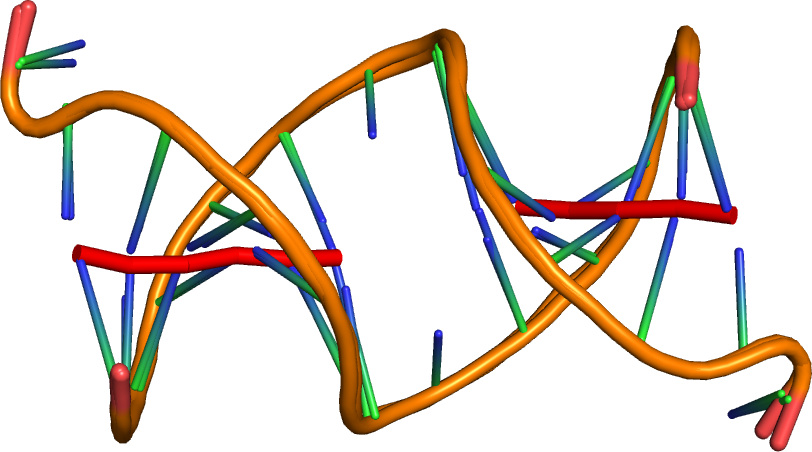


### Example 2: annotate the second structure (R1107TS128_4)

In this section we apply the same `annotator.py` workflow to a different RNA structure:
`R1107TS128_4.pdb`.

The goal is to show that the annotator can be used in an identical way for
different input structures, producing the same types of outputs without any
additional configuration.

As before, the annotator is used to:

- detect RNA base interactions,
- reconstruct the secondary structure,
- export results in multiple standard formats.

Outputs for this structure are stored in:

`../outputs/annotator/R1107TS128_4/`


In [20]:
!mkdir -p ./outputs/annotator/R1107TS128_4

!python ../src/rnapolis/annotator.py \
  ./data/pdb/R1107TS128_4.pdb \
  --csv ./outputs/annotator/R1107TS128_4/interactions.csv \
  --json ./outputs/annotator/R1107TS128_4/structure2d.json \
  --bpseq ./outputs/annotator/R1107TS128_4/structure.bpseq \
  --pml ./outputs/annotator/R1107TS128_4/stems.pml \
  > ./outputs/annotator/R1107TS128_4/dotbracket.txt

In [21]:
!cat ./outputs/annotator/R1107TS128_4/dotbracket.txt

>strand_0
GGGGGCCACAGCAGAAGCGUUCACGUCGCAGCCCCUGUCAGCCAUUGCACUCCGGCUGCGAAUUCUGCU
[[[[[[...((((((((((.......))).]]]]]]........((..............)))))))))


In [22]:
df_casp = pd.read_csv("./outputs/annotator/R1107TS128_4/interactions.csv").fillna("")
df_casp[df_casp["type"] == "base pair"]

,nt1,nt2,type,classification-1,classification-2
0,0.G1,0.U36,base pair,cWW,XXVIII
1,0.G2,0.C35,base pair,cWW,XIX
2,0.G3,0.C34,base pair,cWW,XIX
3,0.G4,0.C33,base pair,cWW,XIX
4,0.G5,0.C32,base pair,cWW,XIX
5,0.C6,0.G31,base pair,cWW,XIX
6,0.A10,0.U69,base pair,cWW,XX
7,0.G11,0.C68,base pair,cWW,XIX
8,0.C12,0.G67,base pair,cWW,XIX
9,0.A13,0.U66,base pair,cWW,XX


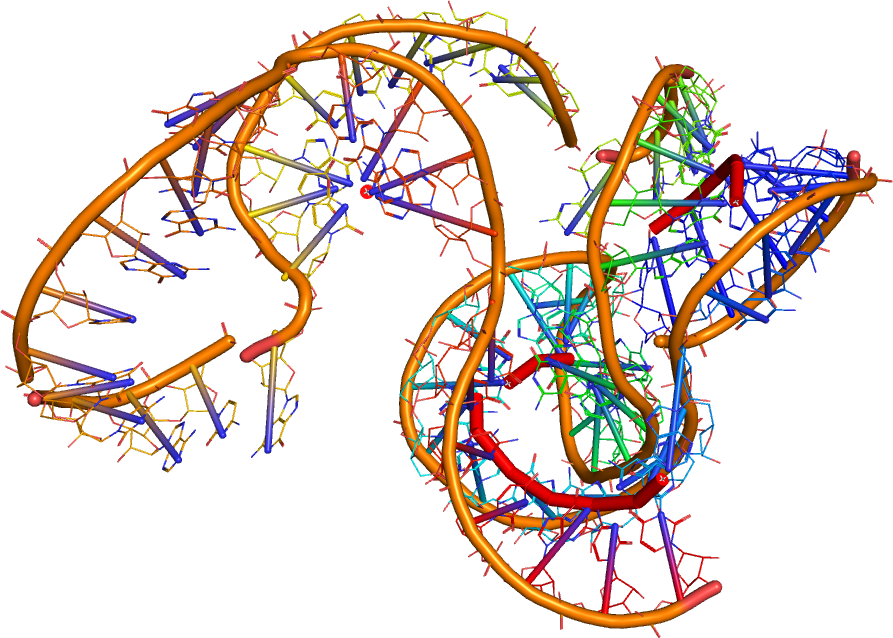


# Inspecting stacking interactions


**5G35:**


In [23]:
df_5g35[df_5g35["type"] == "stacking"]

,nt1,nt2,type,classification-1,classification-2
16,D.DG1,E.DG1,stacking,upward,
17,D.DG9,E.DC10,stacking,upward,
18,E.DC2,E.DT3,stacking,upward,
19,E.DT3,E.DC4,stacking,upward,
20,E.DC4,E.DT5,stacking,upward,
21,E.DT5,E.DA6,stacking,upward,
22,E.DA6,E.DC7,stacking,upward,
23,E.DT9,E.DC10,stacking,upward,
24,E.DC10,E.DA11,stacking,upward,
25,E.DA11,E.DT12,stacking,upward,


**R1107TS128_4:**


In [24]:
df_casp[df_casp["type"] == "stacking"]

,nt1,nt2,type,classification-1,classification-2
20,0.G1,0.G2,stacking,upward,
21,0.G2,0.G3,stacking,upward,
22,0.G3,0.G4,stacking,upward,
23,0.G4,0.G5,stacking,upward,
24,0.G5,0.C6,stacking,upward,
25,0.G5,0.C33,stacking,inward,
26,0.C7,0.A8,stacking,upward,
27,0.A8,0.C9,stacking,upward,
28,0.A10,0.G11,stacking,upward,
29,0.G11,0.C12,stacking,upward,


These output show stacking interactions between nucleotides together with
their relative topology (for example inward, outward, upward or downward),
which reflects the geometric arrangement of the bases.


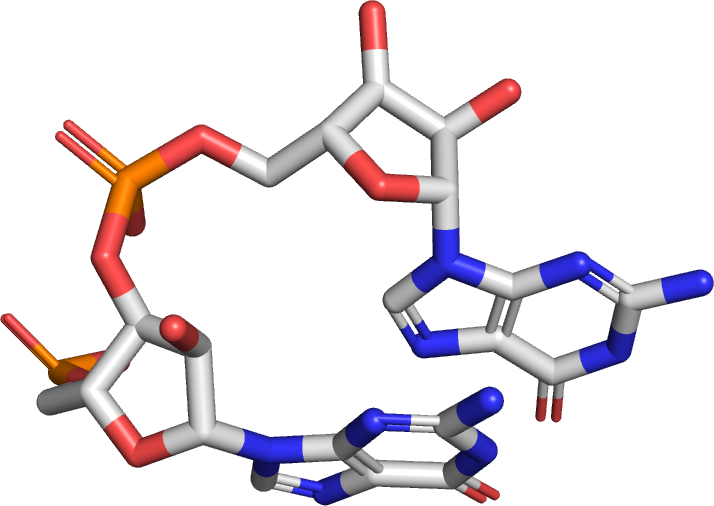


![](stacking.png)


## Inspecting base–phosphate and base–ribose interactions

The annotator also detects non-canonical interactions involving the RNA backbone:

- base–phosphate interactions,
- base–ribose interactions.

These interactions are important for stabilizing RNA tertiary structure
and are reported separately in the interactions table.


#### base-phosphate interactions


**5G35:**


In [25]:
df_5g35[df_5g35["type"] == "base-phosphate interaction"]

,nt1,nt2,type,classification-1,classification-2
38,D.DT2,E.DC2,base-phosphate interaction,9BPh,
39,D.DA4,E.DC4,base-phosphate interaction,0BPh,
40,E.DA6,D.DG6,base-phosphate interaction,0BPh,
41,E.8PY8,D.DC8,base-phosphate interaction,1BPh,
42,E.DT9,D.DG9,base-phosphate interaction,0BPh,
43,E.DC10,D.DT10,base-phosphate interaction,0BPh,
44,F.DG6,C.DT5,base-phosphate interaction,0BPh,
45,F.DA11,F.DT10,base-phosphate interaction,0BPh,


**R1107TS128_4:**


In [26]:
df_casp[df_casp["type"] == "base-phosphate interaction"]

,nt1,nt2,type,classification-1,classification-2
78,0.G37,0.C22,base-phosphate interaction,5BPh,


<br><br>


#### base-ribose interactions


**5G35:**


In [27]:
df_5g35[df_5g35["type"] == "base-ribose interaction"]

,nt1,nt2,type,classification-1,classification-2
46,C.DC7,F.DA7,base-ribose interaction,0BR,
47,C.DT12,F.DG12,base-ribose interaction,0BR,
48,D.DG9,E.DT9,base-ribose interaction,0BR,
49,D.DG12,E.DT12,base-ribose interaction,0BR,
50,E.DG1,D.DG1,base-ribose interaction,0BR,
51,E.DT9,D.DG9,base-ribose interaction,5BR,
52,F.DG14,E.DT3,base-ribose interaction,1BR,


**R1107TS128_4:**


In [28]:
df_casp[df_casp["type"] == "base-ribose interaction"]

,nt1,nt2,type,classification-1,classification-2
79,0.G1,0.U20,base-ribose interaction,0BR,
80,0.G2,0.U36,base-ribose interaction,3BR,
81,0.G3,0.G2,base-ribose interaction,0BR,
82,0.C6,0.C7,base-ribose interaction,0BR,
83,0.G11,0.A10,base-ribose interaction,0BR,
84,0.G17,0.A16,base-ribose interaction,0BR,
85,0.G19,0.U20,base-ribose interaction,1BR,
86,0.A23,0.U21,base-ribose interaction,7BR,
87,0.A23,0.C22,base-ribose interaction,0BR,
88,0.C24,0.G25,base-ribose interaction,0BR,


Each interaction is classified using established interaction codes,
which allows direct comparison with literature descriptions of RNA
backbone-mediated contacts.


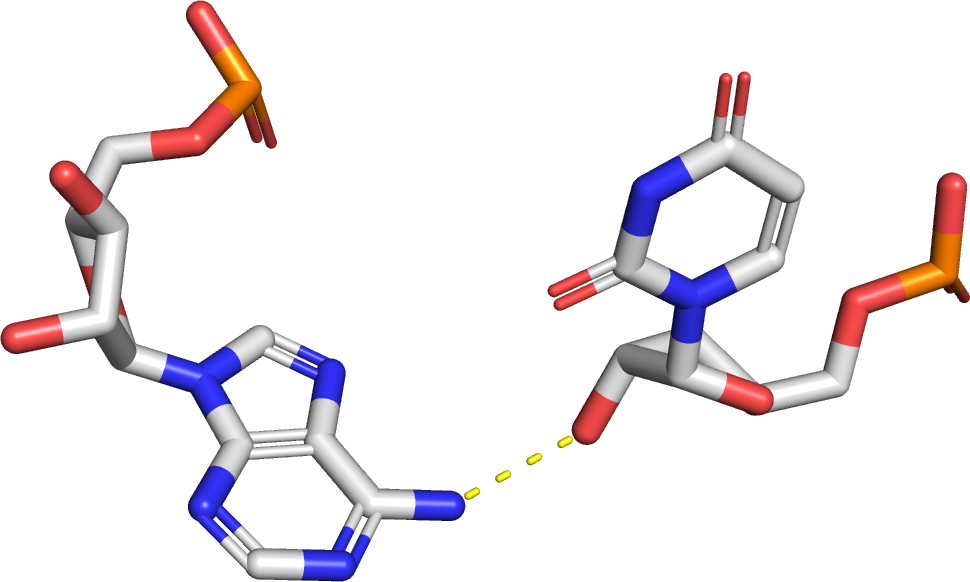


![](base-ribose.png)
